# 5.1. Surprise 라이브러리 기본 사용법

In [1]:
pip install scikit-surprise  # pyright: ignore

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np

from surprise import BaselineOnly, KNNWithMeans,SVD,SVDpp,Dataset,accuracy,Reader
from surprise.model_selection import cross_validate, train_test_split

data = Dataset.load_builtin(name=u'ml-100k')

# train test 분리
trainset,testset = train_test_split(data,test_size=0.25)

algo = KNNWithMeans()

algo.fit(trainset)

predictions = algo.test(testset)

accuracy.rmse(predictions)

Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE: 0.9528


0.9527970412568019

# 5.2. 알고리즘 비교

**BaselineOnly**

- 사용자의 평점평균과 아이템의 평점평균을 모델화해서 예측하는 알고리즘.

**KNNWithMeans**

- chapter_3에서 학습했던 사용자의 평가 경향까지 고려한 CF.

**SVD**

- MF랑 혼돈해서 사용하면 안되는 용어긴 한데...!
- 여기서는 MF 기반 알고리즘을 의미함.

**SVDpp**

- MF 기반. 사용자의 특정 아이템에 대한 평가 여부를 이진값으로 일종의 암묵적 평가까지 추가한 형태.



Estimating biases using als...
RMSE: 0.9422
Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE: 0.9503
RMSE: 0.9349
RMSE: 0.9182


array([0.91815877, 0.93491233, 0.94217144, 0.95031441])

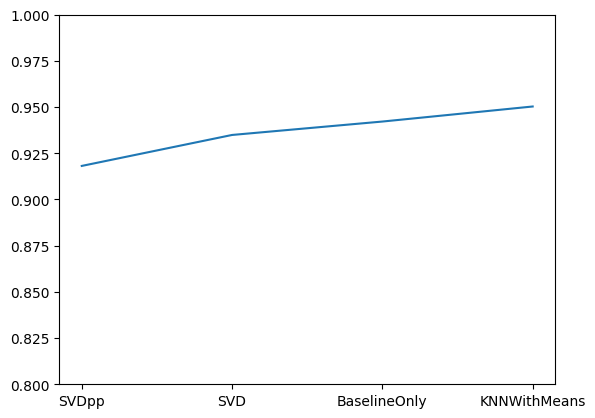

In [3]:
# 비교에 필요한 Surprise 알고리즘
from surprise import BaselineOnly
from surprise import KNNWithMeans
from surprise import SVD
from surprise import SVDpp

# 정확도 측정 관련 모듈을 가져온다.
from surprise import accuracy

# Dataset 관련 모듈을 가져온다.
from surprise import Dataset

# train/test set분리 관련 모듈을 가져온다.
from surprise.model_selection import train_test_split

# 결과를 그래프로 표시하기 위한 라이브러리
import matplotlib.pyplot as plt

# MovieLens 100K 데이터 불러오기
data = Dataset.load_builtin(name=u'ml-100k')

# Train/Test 0.75 : 0.25로 분리
trainset, testset = train_test_split(data, test_size=0.25)


alogorithms = [BaselineOnly,KNNWithMeans,SVD,SVDpp]

names = []
results = []

for option in alogorithms:
  algo = option()
  names.append(option.__name__)
  algo.fit(trainset)
  predictions = algo.test(testset)
  results.append(accuracy.rmse(predictions))
names = np.array(names)
results = np.array(results)

index = np.argsort(results)
plt.ylim(0.8,1)
plt.plot(names[index],results[index])
results[index]

# 5.3. 알고리즘 옵션 지정

(참고) 유사도 지표

![유사도 지표](../static/img_5.png)

In [4]:
sim_options = {'name':'pearson_baseline', # 유사도 지표의 이름
               'user_based':True} # 사용자 기반 유사도 사용 여부 (False면 아이템 기반)
               
algo = KNNWithMeans(k=30,sim_options=sim_options)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
RMSE: 0.9365


0.9364650051996349

# 5.4. 다양한 조건 비교

surprise에 제공되는 기능을 활용해서 다양한 알고리즘에 대한 다양한 인자 테스트를 손쉽게 진행할 수 있음. 

이를 통해 대략적으로 최적의 알고리즘이 무엇인지 초기에 판단할 수 있음.

In [5]:
# 집단과 사용자의 평가경향을 함께 고려한 CF 알고리즘 
from surprise import KNNWithMeans

# Dataset 관련 모듈을 가져온다.
from surprise import Dataset

# 정확도 측정 관련 모듈을 가져온다.
from surprise import accuracy

# train/test set분리 관련 모듈을 가져온다.
from surprise.model_selection import train_test_split

data = Dataset.load_builtin(name=u'ml-100k')

# Train/Test 0.75 : 0.25로 분리
trainset, testset = train_test_split(data, test_size=0.25)


result = []

for neighbor_size in (10,20,30,40,50,60):
  algo = KNNWithMeans(k=neighbor_size,
                      sim_options = {'name':'pearson_baseline',
                                     'user_based':True})
  algo.fit(trainset)
  predictions = algo.test(testset)
  result.append([neighbor_size,accuracy.rmse(predictions)])

result


Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
RMSE: 0.9537
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
RMSE: 0.9415
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
RMSE: 0.9391
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
RMSE: 0.9387
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
RMSE: 0.9390
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
RMSE: 0.9393


[[10, 0.953685251050185],
 [20, 0.9414743144430893],
 [30, 0.9391302629406819],
 [40, 0.9387443617743328],
 [50, 0.9390145375295995],
 [60, 0.9392782719761397]]

In [6]:
# KNN 다양한 파라미터 비교
# Grid Search를 위한 모듈 가져오기
from surprise.model_selection import GridSearchCV

param_grid = {
    'k':[5,10,15,25],
    'sim_options':{
        'name':['pearson_baseline','cosine'],
        'user_based':[True,False]
    }
}

gs = GridSearchCV(KNNWithMeans,
                  param_grid,
                  measures = ['rmse'],
                  cv=4)

gs.fit(data)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similar

In [7]:
# 최적 RMSE 출력
print(gs.best_score['rmse'])

# 최적 RMSE의 parameter 출력
print(gs.best_params['rmse'])

0.9266501388353667
{'k': 25, 'sim_options': {'name': 'pearson_baseline', 'user_based': False}}


# 5.5. 외부 데이터 사용

In [ ]:
# csv 파일에서 불러오기
import pandas as pd
# 데이터 읽기 관련된 모듈을 가져온다.
from surprise import Reader
# Dataset 관련 모듈을 가져온다.
from surprise import Dataset
from pathlib import Path

# DataFrame 형태로 데이터를 읽어온다.
r_cols = ['user_id','movie_id','rating','timestamp']
ratings = pd.read_csv(Path.cwd().parent / 'data' / 'u.data',
                      names=r_cols,
                      sep='\t',
                      encoding='latin-1')

reader = Reader(rating_scale=(1,5)) # 평점 범위 지정
data = Dataset.load_from_df(ratings[['user_id','movie_id','rating']],reader)